# Polygon Distribution Comparison

Use this notebook to compare training polygons against generated polygons with:
- random galleries of aligned shapes
- summary tables and scalar metric distributions
- PCA on aligned polygon coordinates
- aligned vertex-density plots and mean shapes

The workflow canonicalizes translation, scale, orientation, and cyclic vertex offset so that the comparison emphasizes shape differences rather than arbitrary pose.

In [56]:
import importlib
import sys
from pathlib import Path


def ensure_repo_on_path() -> Path:
    cwd = Path.cwd().resolve()
    for root in [cwd, *cwd.parents]:
        if (root / "pyproject.toml").exists() and (root / "polydiff").is_dir():
            root_str = str(root)
            if root_str not in sys.path:
                sys.path.insert(0, root_str)
            return root
    raise RuntimeError(
        "Could not locate repo root. Start Jupyter from this repo or install with: pip install -e .[dev]"
    )


REPO_ROOT = ensure_repo_on_path()

mod = sys.modules.get("polydiff")
if mod is not None:
    mod_file = Path(getattr(mod, "__file__", "") or "")
    if not mod_file.exists() or REPO_ROOT not in mod_file.parents:
        del sys.modules["polydiff"]

polydiff = importlib.import_module("polydiff")
print(f"repo root: {REPO_ROOT}")
print(f"polydiff module: {getattr(polydiff, '__file__', 'unknown')}")

repo root: /Users/jeremyzay/Desktop/thayer_lab_research/2026/spring_2026/polydiff
polydiff module: /Users/jeremyzay/Desktop/thayer_lab_research/2026/spring_2026/polydiff/polydiff/__init__.py


In [57]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from polydiff import paths
from polydiff.data.gen_polygons import (
    centroid_xy,
    edge_lengths,
    enforce_ccw,
    is_self_intersecting,
    normalize_scale_rms,
    polygon_signed_area_xy,
    regularity_score,
)
from polydiff.data.plot_polygons import plot_polygon

plt.style.use("default")
plt.rcParams["figure.dpi"] = 120
pd.options.display.float_format = "{:,.4f}".format

In [58]:
def list_npz_files(folder: Path) -> list[Path]:
    return sorted(folder.glob("*.npz"))


def preferred_or_first(files: list[Path], preferred_name: str, fallback_dir: Path) -> Path:
    preferred = [p for p in files if p.name == preferred_name]
    if preferred:
        return preferred[0]
    if files:
        return files[0]
    return fallback_dir / preferred_name


raw_files = list_npz_files(paths.RAW_DATA_DIR)
processed_files = list_npz_files(paths.PROCESSED_DATA_DIR)

print("Available raw datasets:")
for p in raw_files:
    print(f"  - {p.relative_to(REPO_ROOT)}")

print("\nAvailable processed datasets:")
for p in processed_files:
    print(f"  - {p.relative_to(REPO_ROOT)}")

TRAIN_PATH = preferred_or_first(raw_files, "hexagons.npz", paths.RAW_DATA_DIR)
GENERATED_PATH = preferred_or_first(processed_files, "samples.npz", paths.PROCESSED_DATA_DIR)

MAX_GALLERY = 16
MAX_PCA_SAMPLES_PER_SET = 5000
RANDOM_SEED = 0

print(f"\nSelected training file: {TRAIN_PATH.relative_to(REPO_ROOT) if TRAIN_PATH.exists() else TRAIN_PATH}")
print(f"Selected generated file: {GENERATED_PATH.relative_to(REPO_ROOT) if GENERATED_PATH.exists() else GENERATED_PATH}")

if not TRAIN_PATH.exists() or not GENERATED_PATH.exists():
    raise FileNotFoundError(
        "Update TRAIN_PATH and GENERATED_PATH in this cell to existing .npz files before running the notebook."
    )

Available raw datasets:
  - data/raw/hexagons.npz
  - data/raw/hexagons_noisy.npz
  - data/raw/loud_hex.npz
  - data/raw/pentagons.npz

Available processed datasets:
  - data/processed/samples.npz

Selected training file: data/raw/hexagons.npz
Selected generated file: data/processed/samples.npz


In [59]:
def load_polygon_dataset(file_path: Path, label: str) -> dict[str, object]:
    data = np.load(file_path, allow_pickle=True)
    coords = np.asarray(data["coords"], dtype=np.float32)
    if coords.ndim != 3 or coords.shape[-1] != 2:
        raise ValueError(
            f"{file_path} has invalid coords shape {coords.shape}; expected (num_polygons, n_vertices, 2)"
        )

    n_vertices = int(data["n"]) if "n" in data else int(coords.shape[1])
    if coords.shape[1] != n_vertices:
        raise ValueError(f"{file_path} reports n={n_vertices} but coords.shape[1]={coords.shape[1]}")

    meta: object = {}
    if "meta" in data:
        meta_value = data["meta"]
        if getattr(meta_value, "shape", ()) == ():
            meta = meta_value.item()
        else:
            meta = meta_value.tolist()

    return {
        "label": label,
        "path": file_path,
        "coords": coords,
        "n_vertices": n_vertices,
        "score": np.asarray(data["score"], dtype=np.float32) if "score" in data else None,
        "deform": np.asarray(data["deform"], dtype=np.float32) if "deform" in data else None,
        "meta": meta,
    }


def anchor_index(xy: np.ndarray) -> int:
    return int(np.lexsort((xy[:, 1], -xy[:, 0]))[0])


def canonicalize_polygon(xy: np.ndarray) -> np.ndarray:
    xy = np.asarray(xy, dtype=np.float64)
    xy = xy - centroid_xy(xy)
    xy = normalize_scale_rms(xy)
    xy = enforce_ccw(xy)

    start = anchor_index(xy)
    xy = np.roll(xy, -start, axis=0)

    theta = math.atan2(float(xy[0, 1]), float(xy[0, 0]))
    c = math.cos(-theta)
    s = math.sin(-theta)
    rotation = np.array([[c, -s], [s, c]], dtype=np.float64)
    xy = xy @ rotation.T
    return xy.astype(np.float32)


def polygon_metric_row(xy: np.ndarray) -> tuple[dict[str, float], np.ndarray]:
    xy = canonicalize_polygon(xy)
    reg = regularity_score(xy.astype(np.float64))
    lengths = edge_lengths(xy).astype(np.float64)
    radii = np.linalg.norm(xy, axis=1).astype(np.float64)

    area = abs(polygon_signed_area_xy(xy))
    perimeter = float(lengths.sum())
    compactness = float(4.0 * math.pi * area / (perimeter ** 2 + 1e-12))
    width = float(xy[:, 0].max() - xy[:, 0].min())
    height = float(xy[:, 1].max() - xy[:, 1].min())

    row = {
        "score": float(reg.score),
        "edge_cv": float(reg.edge_cv),
        "angle_cv": float(reg.angle_cv),
        "radius_cv": float(reg.radius_cv),
        "area": float(area),
        "perimeter": perimeter,
        "compactness": compactness,
        "width": width,
        "height": height,
        "bbox_aspect": float(width / (height + 1e-12)),
        "min_radius": float(radii.min()),
        "max_radius": float(radii.max()),
        "min_edge": float(lengths.min()),
        "max_edge": float(lengths.max()),
        "self_intersecting": float(is_self_intersecting(xy)),
    }
    return row, xy


def build_metrics_frame(dataset: dict[str, object]) -> tuple[pd.DataFrame, np.ndarray]:
    coords = np.asarray(dataset["coords"], dtype=np.float32)
    score = dataset["score"]
    deform = dataset["deform"]

    aligned = np.empty_like(coords)
    rows: list[dict[str, float | int | str]] = []
    for i, xy in enumerate(coords):
        row, xy_aligned = polygon_metric_row(xy)
        row["dataset"] = str(dataset["label"])
        row["index"] = i
        if score is not None:
            row["stored_score"] = float(score[i])
            row["score_error"] = row["score"] - row["stored_score"]
        if deform is not None:
            row["deform"] = float(deform[i])
        rows.append(row)
        aligned[i] = xy_aligned

    return pd.DataFrame(rows), aligned


def choose_indices(n: int, count: int, seed: int) -> np.ndarray:
    if n <= count:
        return np.arange(n)
    rng = np.random.default_rng(seed)
    return np.sort(rng.choice(n, size=count, replace=False))


def sample_rows(x: np.ndarray, max_rows: int, seed: int) -> np.ndarray:
    idx = choose_indices(len(x), max_rows, seed)
    return x[idx]


def fit_pca_2d(arrays: dict[str, np.ndarray], max_samples_per_set: int, seed: int) -> tuple[dict[str, np.ndarray], np.ndarray]:
    sampled: dict[str, np.ndarray] = {}
    chunks: list[np.ndarray] = []
    start_seed = seed
    for label, arr in arrays.items():
        flat = arr.reshape(len(arr), -1)
        subset = sample_rows(flat, max_samples_per_set, start_seed)
        sampled[label] = subset
        chunks.append(subset)
        start_seed += 1

    X = np.vstack(chunks)
    X = X - X.mean(axis=0, keepdims=True)
    _, singular_values, vt = np.linalg.svd(X, full_matrices=False)
    components = vt[:2]
    embedded = X @ components.T
    explained = (singular_values[:2] ** 2) / np.sum(singular_values ** 2)

    out: dict[str, np.ndarray] = {}
    offset = 0
    for label, subset in sampled.items():
        next_offset = offset + len(subset)
        out[label] = embedded[offset:next_offset]
        offset = next_offset
    return out, explained


def plot_gallery(coords: np.ndarray, scores: np.ndarray, title: str, *, num: int, seed: int) -> None:
    idx = choose_indices(len(coords), num, seed)
    cols = min(4, len(idx))
    rows = int(math.ceil(len(idx) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3.0 * cols, 3.0 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, i in zip(axes, idx):
        plot_polygon(ax, coords[i], score=float(scores[i]), color_by_score=True)
        ax.set_title(f"score={scores[i]:.3f}", fontsize=8)

    for ax in axes[len(idx):]:
        ax.axis("off")

    fig.suptitle(title, y=1.02)
    fig.tight_layout()


def plot_metric_distributions(df: pd.DataFrame, metrics: list[str], *, bins: int = 40) -> None:
    colors = {"training": "tab:blue", "generated": "tab:orange"}
    cols = 3
    rows = int(math.ceil(len(metrics) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(5.0 * cols, 3.5 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, metric in zip(axes, metrics):
        for label in ["training", "generated"]:
            values = df.loc[df["dataset"] == label, metric].dropna().to_numpy()
            if len(values) == 0:
                continue
            ax.hist(
                values,
                bins=bins,
                density=True,
                alpha=0.25,
                histtype="stepfilled",
                linewidth=2,
                color=colors.get(label, None),
                label=f"{label} (n={len(values)})",
            )
            ax.axvline(values.mean(), linestyle="--", linewidth=1.5, color=colors.get(label, None))
        ax.set_title(metric.replace("_", " "))
        ax.legend()

    for ax in axes[len(metrics):]:
        ax.axis("off")

    fig.tight_layout()


def plot_vertex_density(ax, coords: np.ndarray, title: str, *, cmap: str):
    pts = coords.reshape(-1, 2)
    hexbin = ax.hexbin(pts[:, 0], pts[:, 1], gridsize=35, mincnt=1, cmap=cmap)
    mean_poly = coords.mean(axis=0)
    mean_closed = np.vstack([mean_poly, mean_poly[0]])
    ax.plot(mean_closed[:, 0], mean_closed[:, 1], color="white", linewidth=2.5)
    ax.scatter(mean_poly[:, 0], mean_poly[:, 1], s=18, color="white", edgecolors="black", linewidths=0.4)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)
    return hexbin

## Dataset Overview

This table is a quick sanity check before looking at any plots.

How to interpret it:
- `num_polygons` tells you whether you are comparing similarly sized samples or a small generated batch against a large training set.
- `n_vertices` must match. If it does not, the rest of the notebook is not a meaningful comparison.
- `has_stored_score` and `has_deform` tell you which extra annotations are available from the file itself.
- The `meta` field printed below the table is mainly provenance: checkpoint path, sample count, diffusion steps, and similar run details.

What to expect with the default inputs:
- The training file should be a synthetic fixed-`n` polygon dataset, usually `data/raw/hexagons.npz`.
- The generated file should be a sample batch from the diffusion model, usually `data/processed/samples.npz`.
- Both should report the same number of vertices because the current model is trained for a fixed polygon size.

In [60]:
training = load_polygon_dataset(TRAIN_PATH, "training")
generated = load_polygon_dataset(GENERATED_PATH, "generated")

if training["n_vertices"] != generated["n_vertices"]:
    raise ValueError(
        f"Vertex count mismatch: training has n={training['n_vertices']} and generated has n={generated['n_vertices']}"
    )

train_metrics, train_aligned = build_metrics_frame(training)
gen_metrics, gen_aligned = build_metrics_frame(generated)
combined_metrics = pd.concat([train_metrics, gen_metrics], ignore_index=True)

dataset_overview = pd.DataFrame(
    [
        {
            "dataset": training["label"],
            "path": str(Path(training["path"]).relative_to(REPO_ROOT)),
            "num_polygons": len(training["coords"]),
            "n_vertices": training["n_vertices"],
            "has_stored_score": training["score"] is not None,
            "has_deform": training["deform"] is not None,
        },
        {
            "dataset": generated["label"],
            "path": str(Path(generated["path"]).relative_to(REPO_ROOT)),
            "num_polygons": len(generated["coords"]),
            "n_vertices": generated["n_vertices"],
            "has_stored_score": generated["score"] is not None,
            "has_deform": generated["deform"] is not None,
        },
    ]
)

dataset_overview

,dataset,path,num_polygons,n_vertices,has_stored_score,has_deform
0,training,data/raw/hexagons.npz,10000,6,True,True
1,generated,data/processed/samples.npz,1000,6,False,False


## Raw And Aligned Galleries

These galleries intentionally show each dataset twice. The raw galleries use the polygons exactly as stored in the `.npz` files. The aligned galleries use canonicalized polygons, so translation, scale, CCW ordering, cyclic vertex start, and global rotation have been normalized.

How to interpret them:
- If the raw gallery shows many rotations of the same shape family, that is expected. Training and sampling keep those rotations.
- If the aligned gallery looks tightly lined up, that is also expected. The notebook explicitly rotates and reindexes polygons before plotting.
- Compare raw galleries to answer `what does the model actually emit?`.
- Compare aligned galleries to answer `are the underlying shapes similar once pose and indexing are removed?`.
- If raw generated polygons already look badly distorted, the model is failing even before alignment.
- If raw galleries differ mainly by rotation but aligned galleries match well, the model may be learning shape better than the raw view first suggests.
- The title score is the recomputed regularity score; the polygon is the same sample in both views, only the visualization changes.

What to expect with the default inputs:
- Raw training hexagons should appear centered and similarly scaled, but rotated arbitrarily.
- Raw generated polygons should also be rotated arbitrarily if sampling learned the same pose convention.
- Aligned training and generated galleries should look much more uniform in orientation because `canonicalize_polygon(...)` explicitly rolls vertices and rotates each polygon to a fixed anchor.
- Within each dataset, the raw and aligned gallery calls below use the same seed, so you should be looking at the same subset of polygons before and after canonicalization.

training stored-vs-recomputed score max abs error: 7.577473999376139e-07
generated meta: {'checkpoint': '/Users/jeremyzay/Desktop/thayer_lab_research/2026/spring_2026/polydiff/models/diffusion_final.pt', 'num_samples': 1000, 'n_steps': 200, 'checkpoint_n_steps': 200}


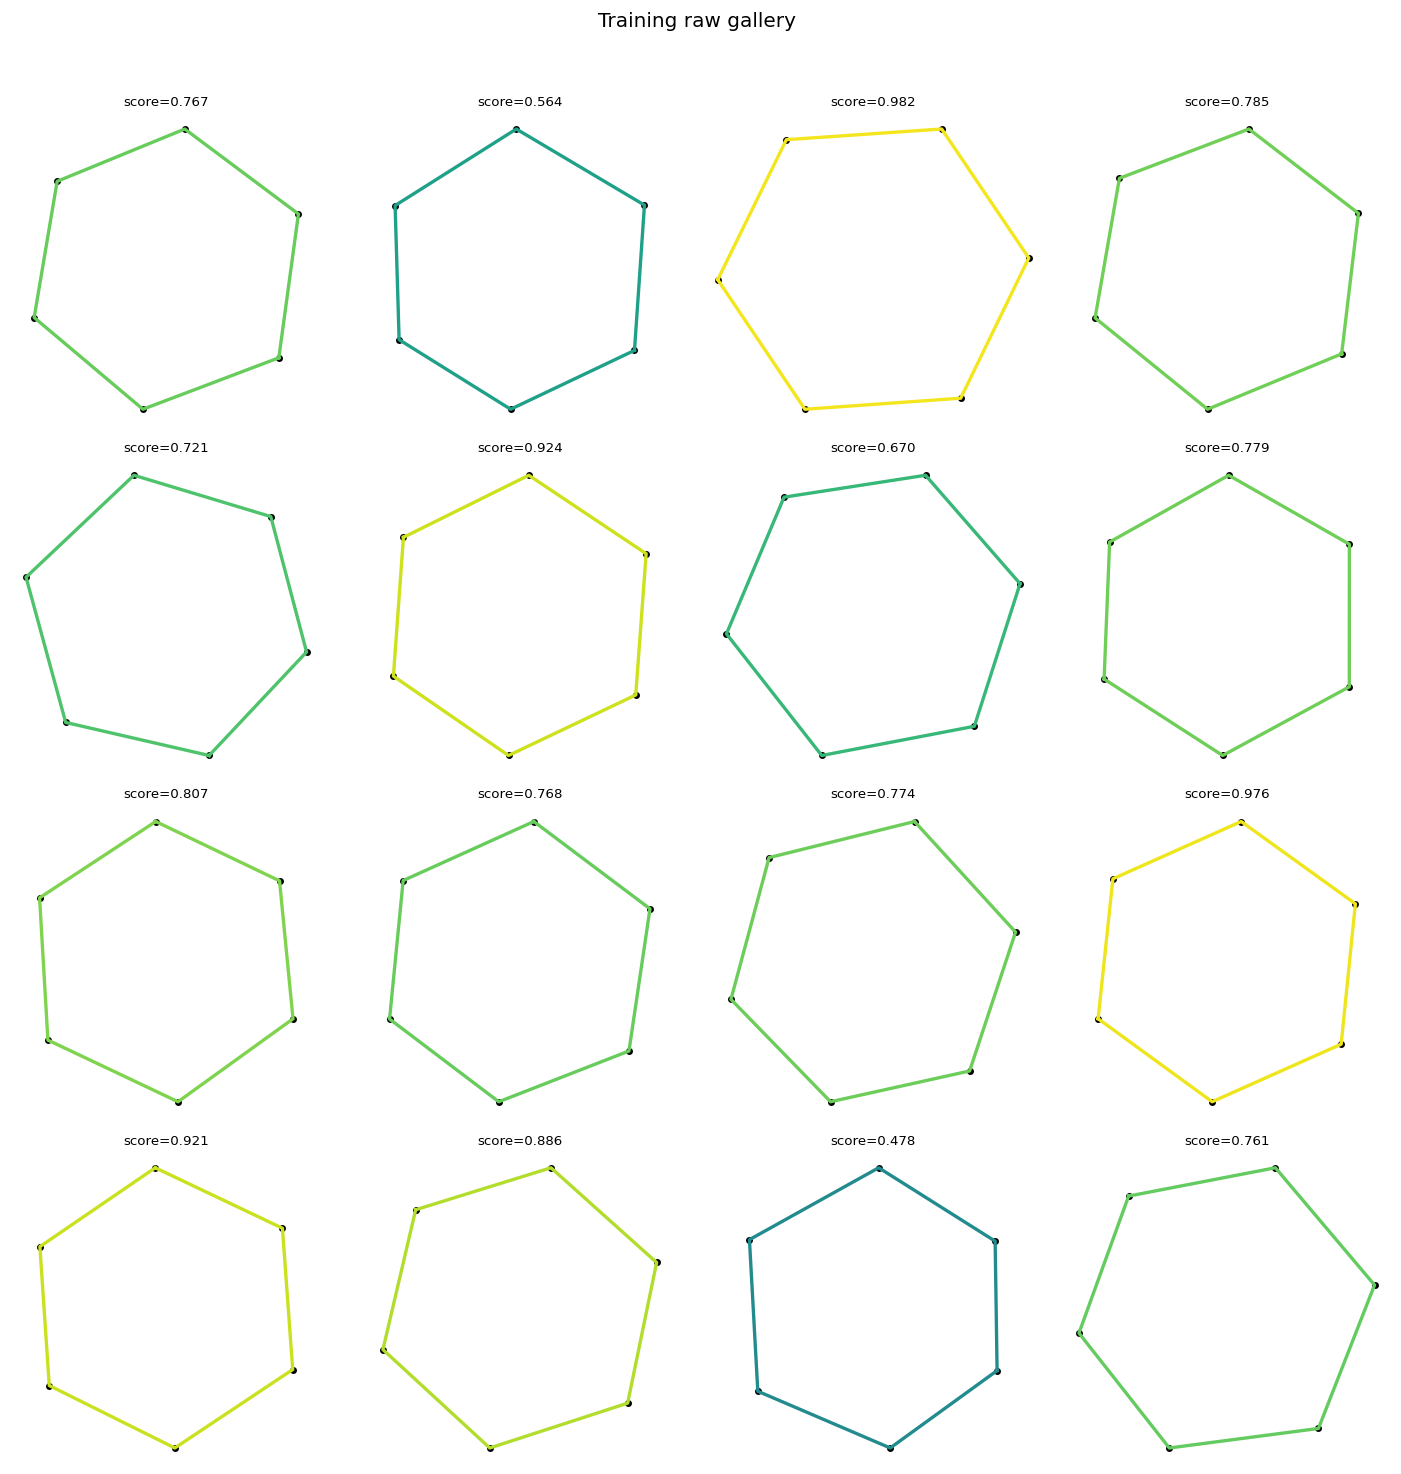

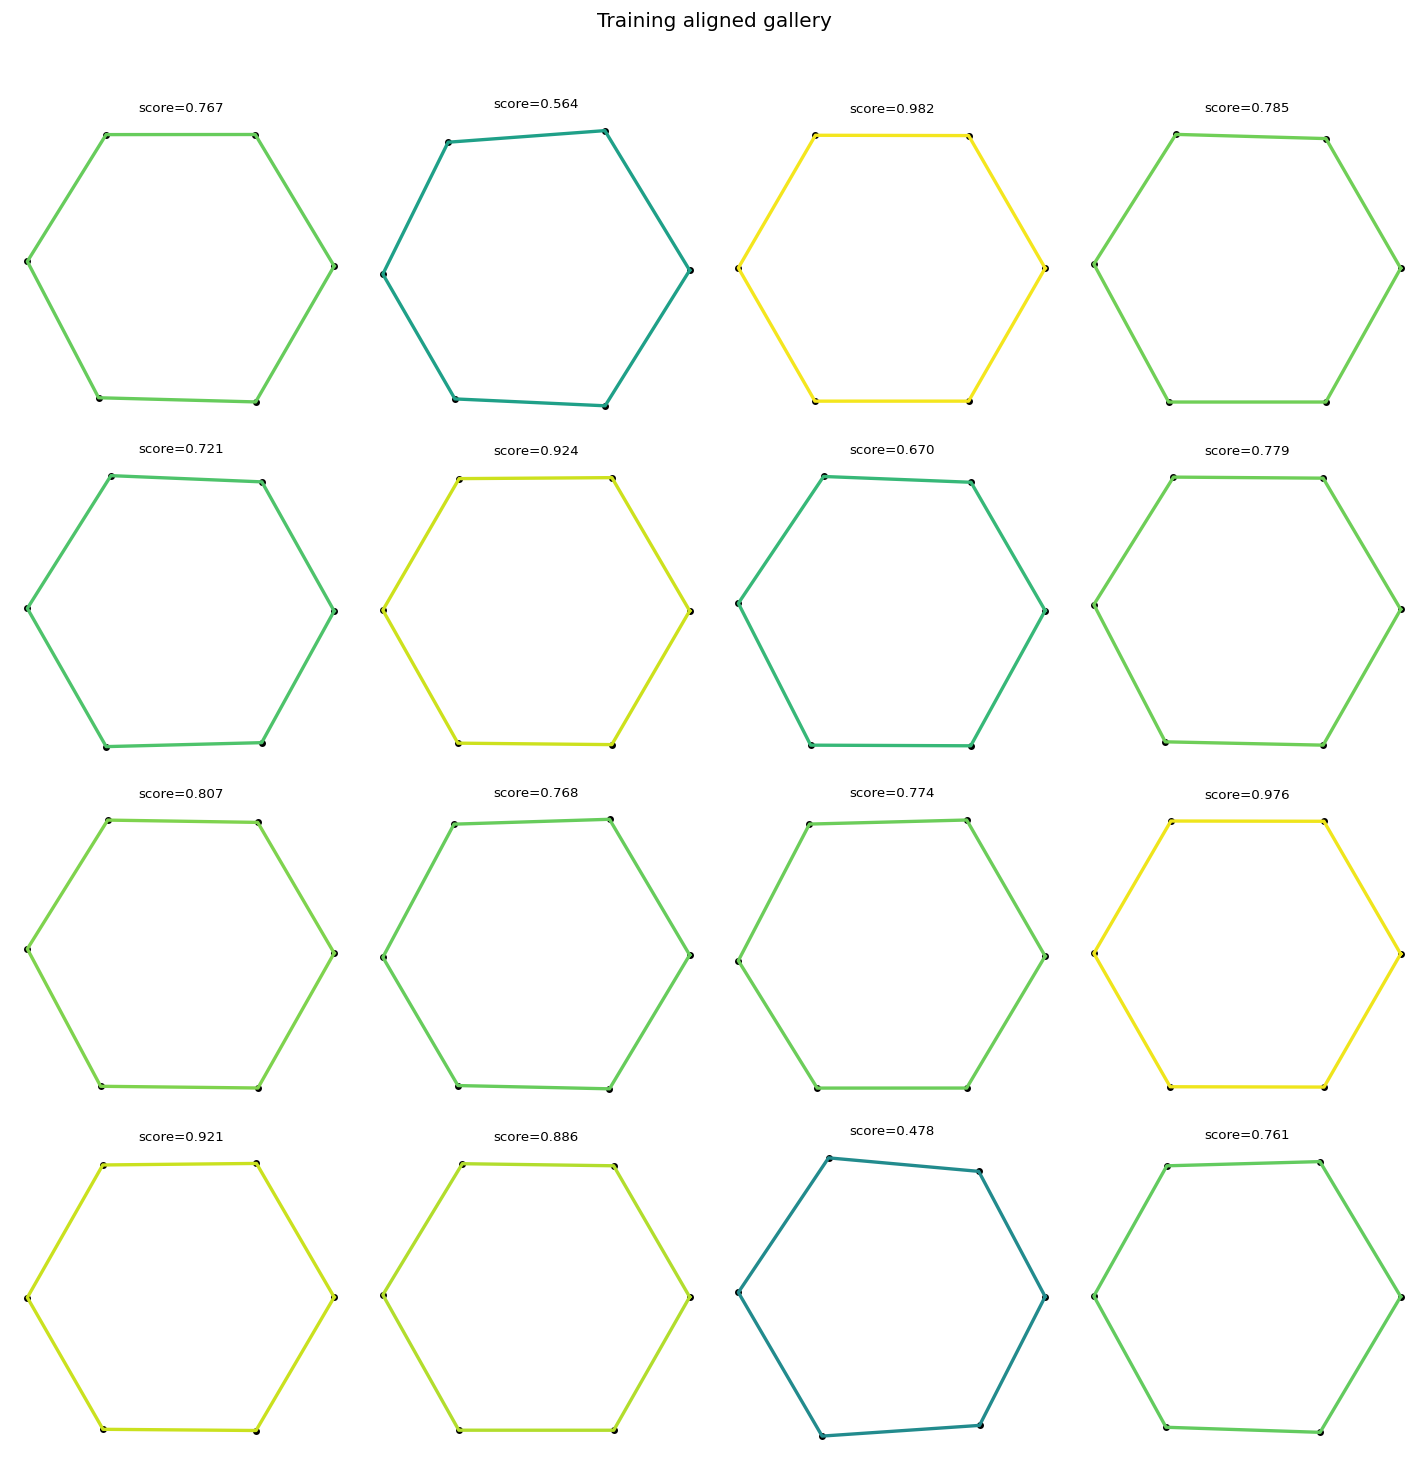

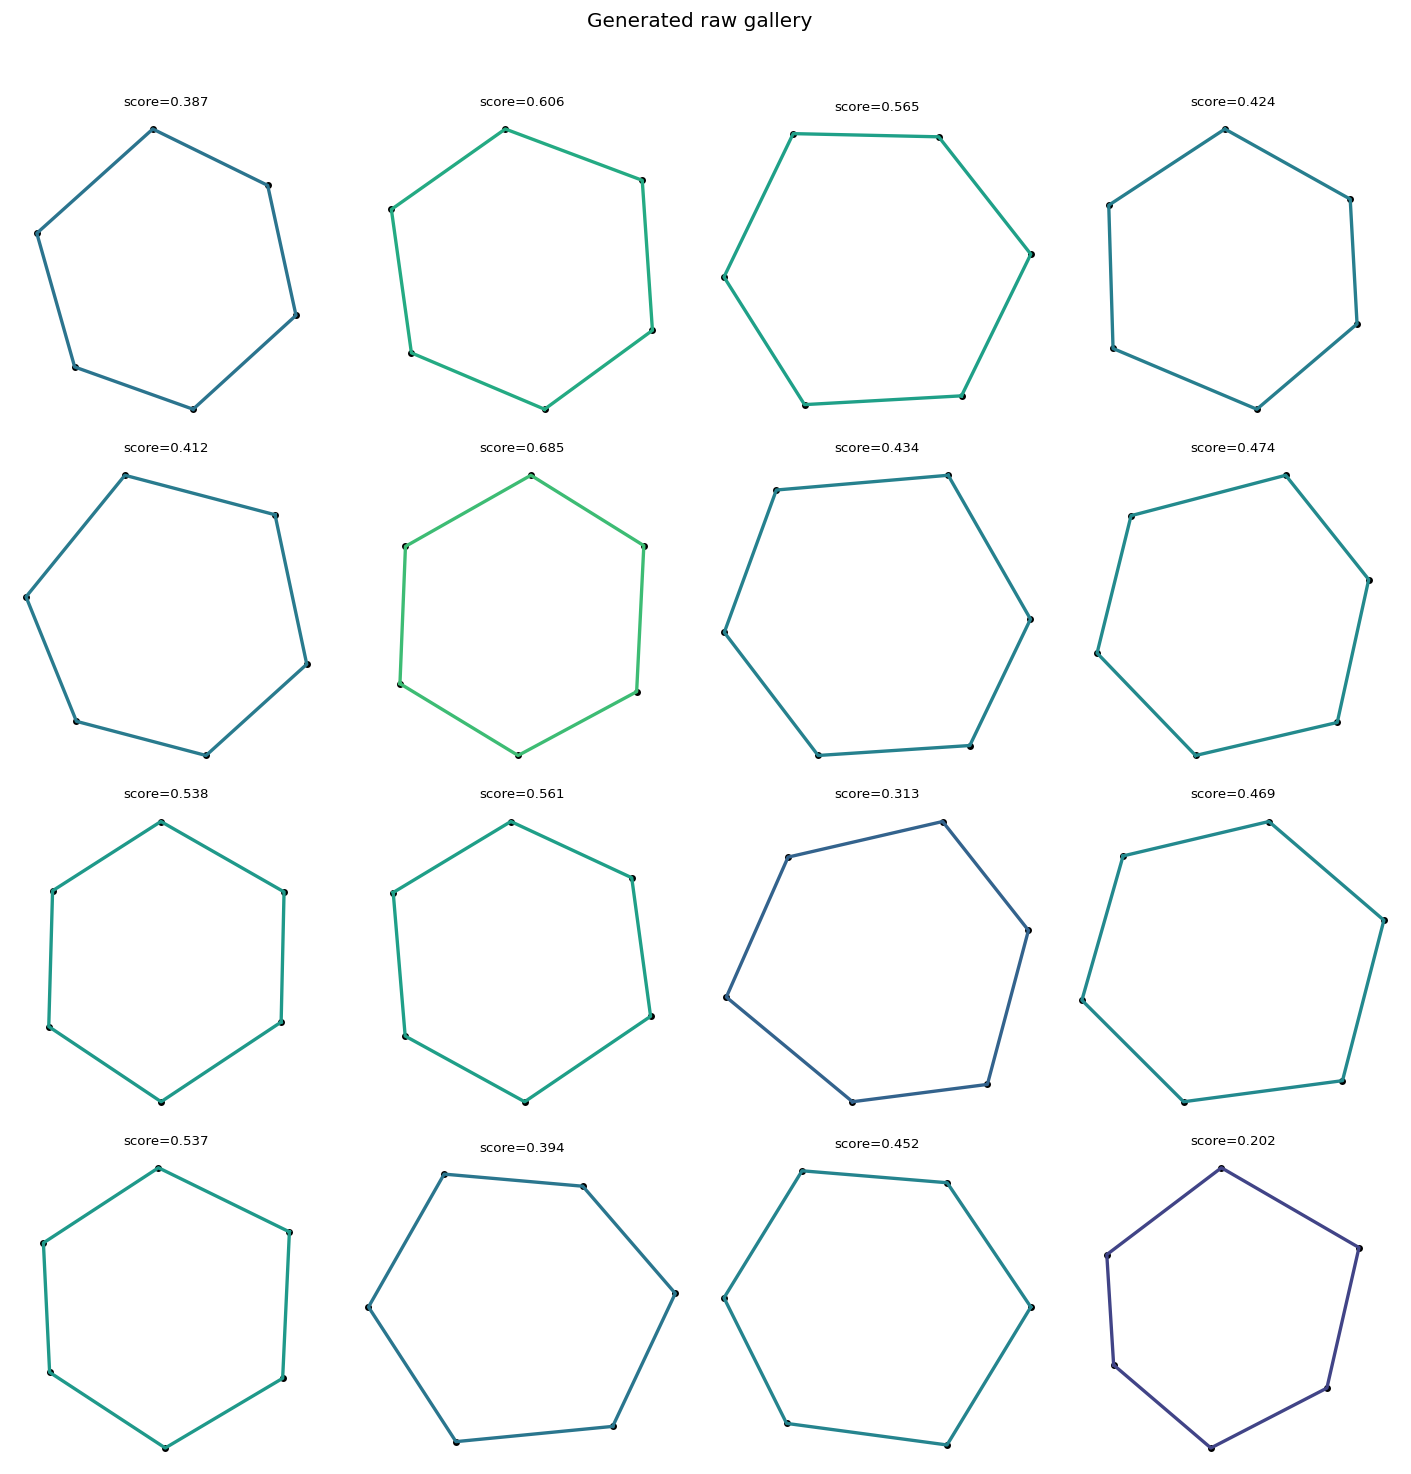

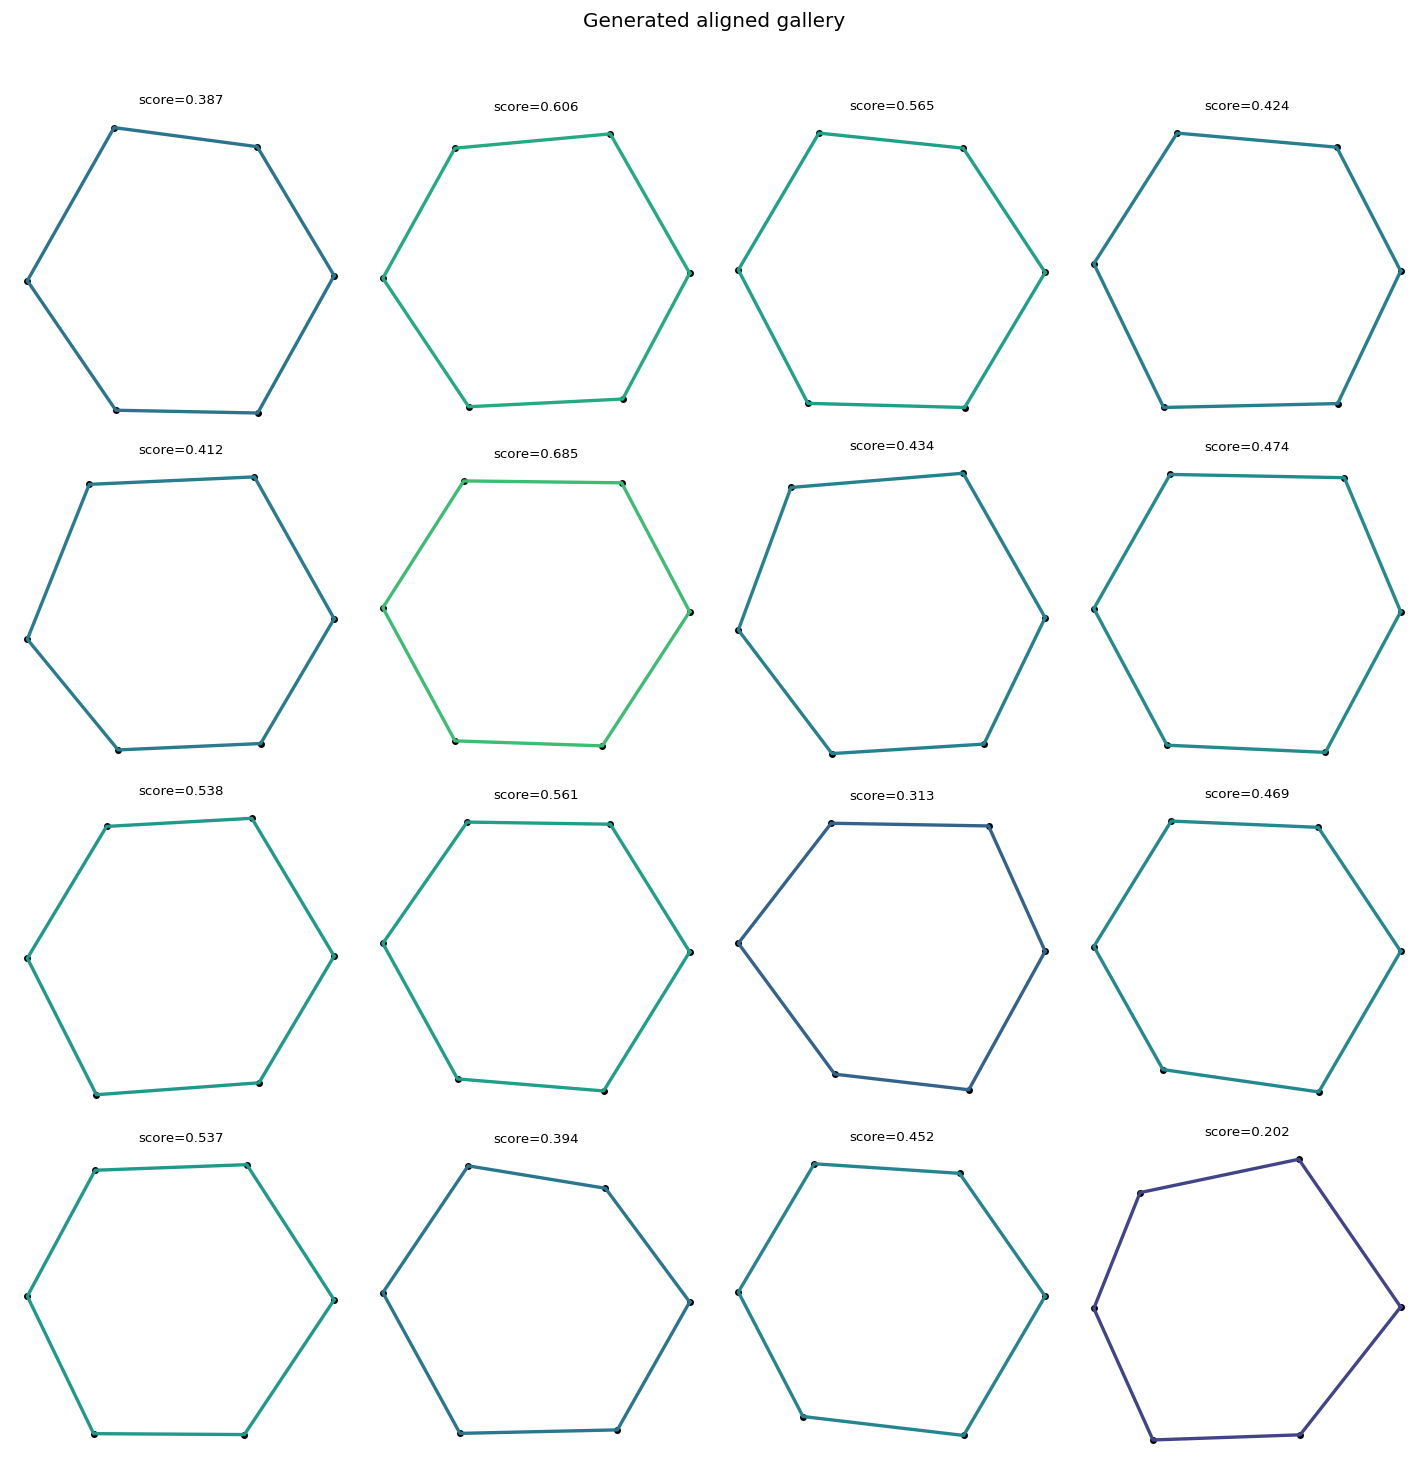

In [61]:
if "score_error" in train_metrics.columns:
    print(
        "training stored-vs-recomputed score max abs error:",
        float(train_metrics["score_error"].abs().max()),
    )

if training["meta"]:
    print("training meta:", training["meta"])
if generated["meta"]:
    print("generated meta:", generated["meta"])

train_scores = train_metrics["score"].to_numpy()
gen_scores = gen_metrics["score"].to_numpy()

plot_gallery(training["coords"], train_scores, "Training raw gallery", num=MAX_GALLERY, seed=RANDOM_SEED)
plot_gallery(train_aligned, train_scores, "Training aligned gallery", num=MAX_GALLERY, seed=RANDOM_SEED)
plot_gallery(generated["coords"], gen_scores, "Generated raw gallery", num=MAX_GALLERY, seed=RANDOM_SEED + 1)
plot_gallery(gen_aligned, gen_scores, "Generated aligned gallery", num=MAX_GALLERY, seed=RANDOM_SEED + 1)


## Summary Table

This condenses the two datasets into a few aggregate statistics.

How to interpret it:
- `mean_score` and `median_score` summarize overall regularity. Large gaps between training and generated mean the model is biased toward either overly regular or overly irregular polygons.
- `std_score` measures spread. If generated `std_score` is much smaller than training, the model is under-dispersed and missing extremes.
- `self_intersection_rate` should ideally be near zero for both. A higher generated rate means the model is leaving the valid polygon manifold.
- `mean_edge_cv`, `mean_angle_cv`, and `mean_radius_cv` are the components behind the score. If one of these differs much more than the others, it tells you what type of distortion the model is getting wrong.
- `mean_area` and `mean_compactness` help separate shape mismatch from score mismatch. Since polygons are RMS-normalized, compactness is usually more informative than raw area.

What to expect with the default inputs:
- Training and generated values should be in the same ballpark if the diffusion model is learning the synthetic dataset.
- It is common for the generated set to be slightly narrower and slightly more central than training, especially if the checkpoint is early or the model is conservative.

In [62]:
summary_table = (
    combined_metrics.groupby("dataset")
    .agg(
        count=("index", "size"),
        mean_score=("score", "mean"),
        median_score=("score", "median"),
        std_score=("score", "std"),
        self_intersection_rate=("self_intersecting", "mean"),
        mean_edge_cv=("edge_cv", "mean"),
        mean_angle_cv=("angle_cv", "mean"),
        mean_radius_cv=("radius_cv", "mean"),
        mean_area=("area", "mean"),
        mean_compactness=("compactness", "mean"),
    )
    .sort_index()
)
summary_table

,count,mean_score,median_score,std_score,self_intersection_rate,mean_edge_cv,mean_angle_cv,mean_radius_cv,mean_area,mean_compactness
dataset,,,,,,,,,,
generated,1000,0.4631,0.4635,0.1076,0.0010,0.0594,0.0410,0.0349,2.5903,0.9031
training,10000,0.7866,0.8058,0.1313,0.0000,0.0201,0.0097,0.0116,2.5981,0.9067


## Scalar Metric Distributions

These histograms compare one scalar metric at a time. The dashed line is the mean for each dataset.

How to interpret them:
- Strong overlap is good: it means the generated marginal distribution matches training for that feature.
- A generated curve shifted to the right of training means the model is systematically producing larger values for that metric.
- A generated curve shifted to the left means the model is systematically producing smaller values.
- A much narrower generated curve means the model is under-dispersed and is missing some variability in the data.
- A much wider generated curve means the model is injecting too much variability or creating off-manifold shapes.

Feature-specific interpretation:
- `score`: higher means more regular. If generated is too far right, samples are too perfect or averaged. If too far left, samples are too noisy or distorted.
- `edge_cv`, `angle_cv`, `radius_cv`: lower means more regular. A mismatch here identifies which geometric property is off.
- `area`: after RMS normalization, this is still shape-dependent. Large shifts mean the overall shape family differs.
- `compactness`: closer to 1 means more circle-like and efficient; lower values mean more spiky or elongated shapes.

What to expect with the default inputs:
- The training distributions come from the synthetic polygon generator, so they should be smooth and unimodal rather than multi-peaked.
- A decent unguided generator should overlap training reasonably well but often with slightly less spread, especially in the tails.

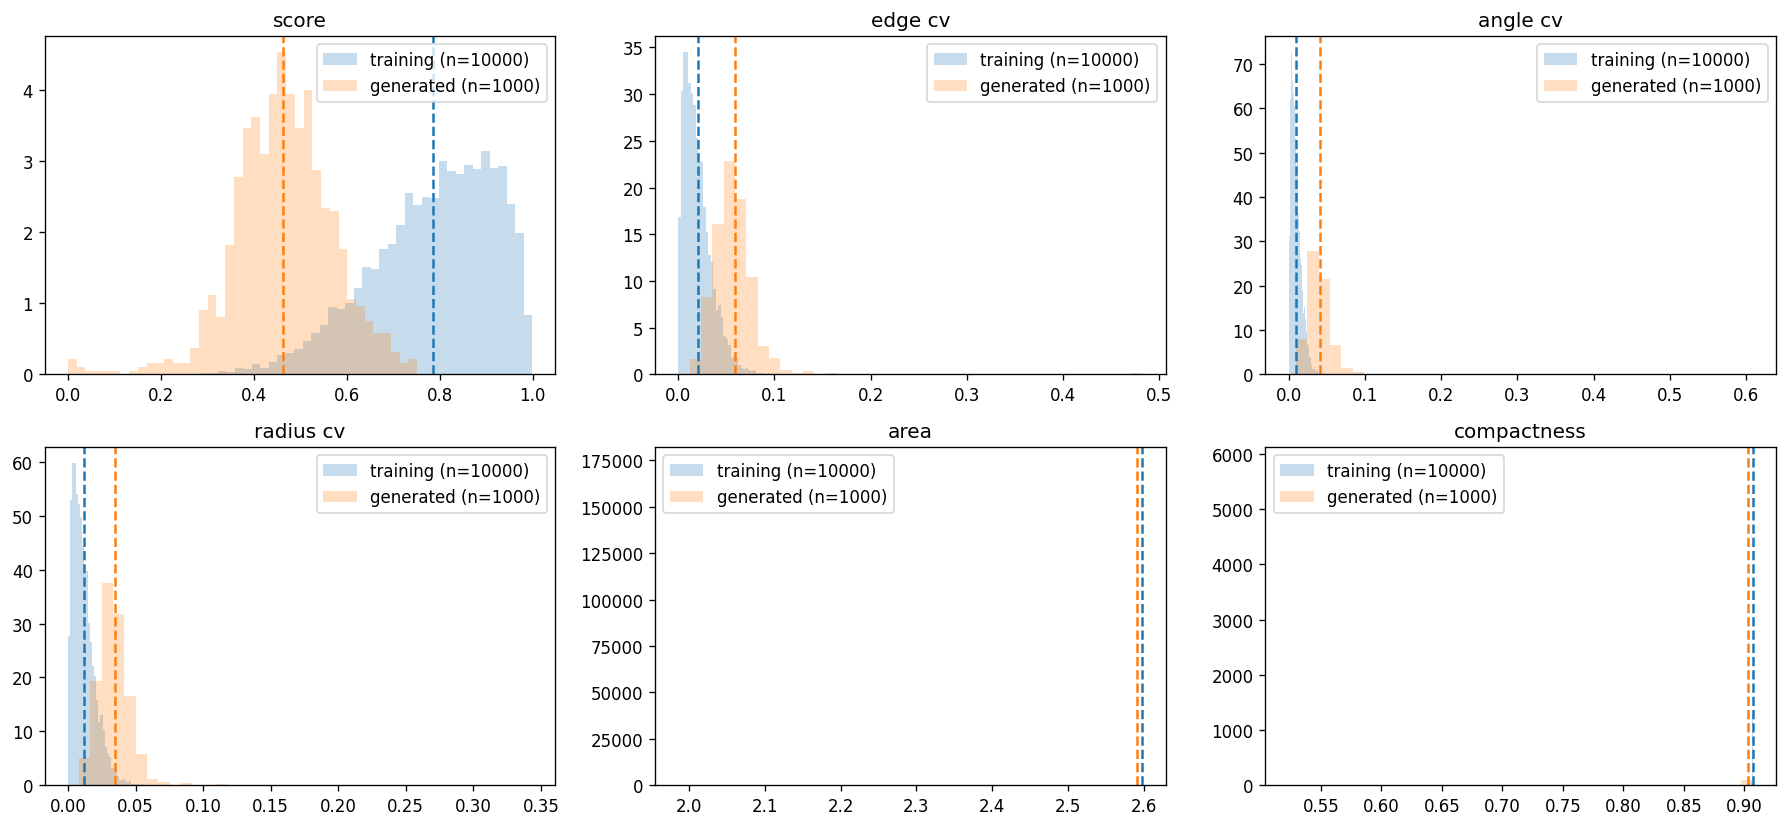

In [63]:
metrics_to_plot = [
    "score",
    "edge_cv",
    "angle_cv",
    "radius_cv",
    "area",
    "compactness",
]

plot_metric_distributions(combined_metrics, metrics_to_plot, bins=40)

## PCA Of Aligned Shapes

This projects each aligned polygon into two principal components of the flattened coordinate space. It is a coarse view of whole-shape similarity, not just one scalar feature at a time.

How to interpret it:
- If the generated cloud overlaps the training cloud, the model is capturing the same broad shape manifold.
- If the generated cloud sits inside the training cloud but is much tighter, the model is learning the center of the distribution but missing diversity.
- If the generated cloud is offset from training, the model has a systematic bias in shape space.
- If you see separate blobs in generated but not training, the model may be inventing artificial modes or artifacts.
- If training has regions with no generated coverage, those are modes the model is missing.

What to expect with the default inputs:
- Because both datasets are aligned fixed-vertex polygons, the main variation should come from how far each sample deviates from a regular polygon.
- A reasonable unguided model should produce a generated cloud that mostly overlaps training, though it may be somewhat tighter if the model prefers average shapes.

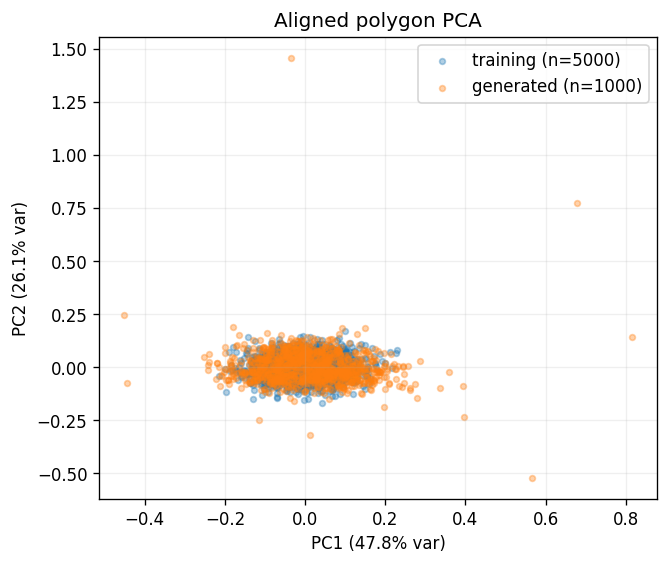

In [64]:
pca_inputs = {
    "training": train_aligned,
    "generated": gen_aligned,
}
pca_points, explained = fit_pca_2d(pca_inputs, MAX_PCA_SAMPLES_PER_SET, RANDOM_SEED)

fig, ax = plt.subplots(figsize=(6.0, 5.0))
colors = {"training": "tab:blue", "generated": "tab:orange"}
for label, pts in pca_points.items():
    ax.scatter(pts[:, 0], pts[:, 1], s=12, alpha=0.35, color=colors[label], label=f"{label} (n={len(pts)})")

ax.set_xlabel(f"PC1 ({explained[0]:.1%} var)")
ax.set_ylabel(f"PC2 ({explained[1]:.1%} var)")
ax.set_title("Aligned polygon PCA")
ax.legend()
ax.grid(alpha=0.2)

## Vertex Density And Mean Polygon

Each panel stacks many aligned polygons together. The colored density shows where vertices occur most often, and the white outline is the mean polygon.

How to interpret it:
- If training and generated density lobes line up, the model is putting vertices in the right places on average.
- If generated density is much more concentrated than training, the model is producing too little shape diversity.
- If generated density is much more diffuse, the model is too noisy or unstable.
- If the white mean polygon is noticeably different between panels, the model has a systematic bias in average shape.
- If one or more lobes shift or smear asymmetrically, the model may be getting particular vertices or local deformations wrong after alignment.

What to expect with the default inputs:
- For fixed-vertex near-regular polygons, you should see a ring of repeated high-density lobes corresponding to the aligned vertex locations.
- Generated density should broadly match training. A common failure mode is overly sharp lobes, which indicates samples are collapsing toward a canonical average polygon.

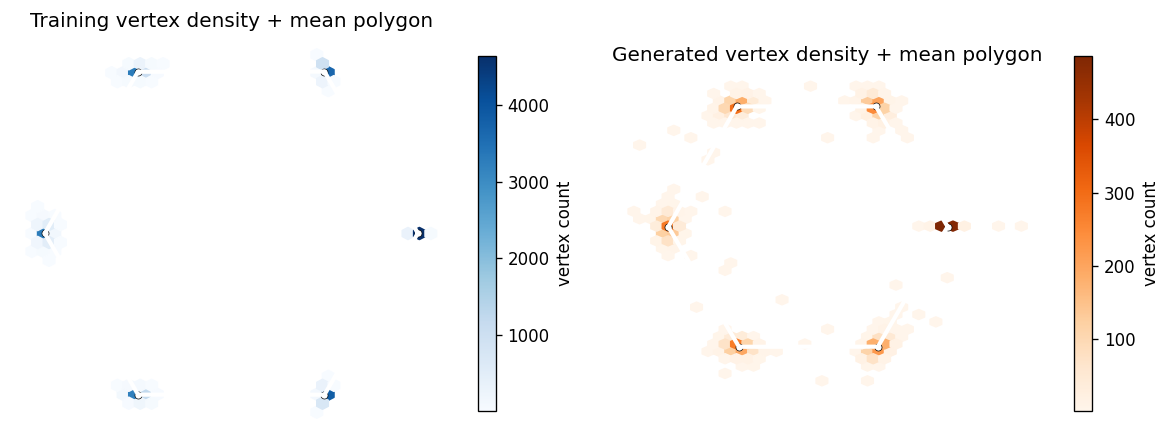

In [65]:
train_density = sample_rows(train_aligned, MAX_PCA_SAMPLES_PER_SET, RANDOM_SEED)
gen_density = sample_rows(gen_aligned, MAX_PCA_SAMPLES_PER_SET, RANDOM_SEED + 1)

fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.0))
hb_train = plot_vertex_density(axes[0], train_density, "Training vertex density + mean polygon", cmap="Blues")
hb_gen = plot_vertex_density(axes[1], gen_density, "Generated vertex density + mean polygon", cmap="Oranges")
fig.colorbar(hb_train, ax=axes[0], shrink=0.8, label="vertex count")
fig.colorbar(hb_gen, ax=axes[1], shrink=0.8, label="vertex count")
fig.tight_layout()

## Training Deform vs Score

This plot only exists for datasets that store the generator's `deform` value. It is mainly a calibration check for the synthetic training distribution.

How to interpret it:
- You should see a clear negative relationship: higher deformation should correspond to lower regularity score.
- If the relationship is weak or upside down, either the stored data is not what you think it is or the score is not capturing the intended notion of regularity.
- If the cloud is very narrow in `deform`, the training set may not cover enough variation to teach a broad distribution.
- If there are visible horizontal bands or strange clusters, that can signal discretization, dataset assembly issues, or a hidden subpopulation.

What to expect with the default inputs:
- The training generator defines regularity from edge, angle, and radius variation, and `deform` directly controls those perturbations, so the trend should be strongly negative.
- Because `deform` is sampled from a beta distribution, there are usually more medium-deformation points than extreme ones.

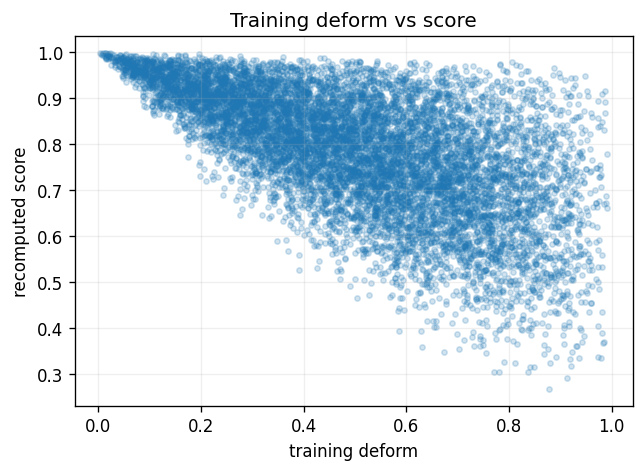

In [66]:
if "deform" in train_metrics.columns:
    fig, ax = plt.subplots(figsize=(6.0, 4.0))
    ax.scatter(train_metrics["deform"], train_metrics["score"], s=10, alpha=0.2, color="tab:blue")
    ax.set_xlabel("training deform")
    ax.set_ylabel("recomputed score")
    ax.set_title("Training deform vs score")
    ax.grid(alpha=0.2)
else:
    print("Training file has no deform field.")